# 第26篇｜交互式可视化：Plotly 入门

> 这是「数据分析从入门到精通」系列的第 26 篇。静态图表讲完了，这篇来认识交互式可视化——Plotly。可以缩放、点击、悬浮查看数据，用于数据报告和 Web 展示，逼格直接拉满。

---

嗨，我是小荷～

Matplotlib 和 Seaborn 画出来的是静态图，适合报告和 PDF。但如果你要把分析发给别人看，或者做一个在线展示，**静态图有个致命缺点——看不到具体数值，也不能缩放**。

这时候就该 Plotly 出场了。Plotly 生成的图表是**交互式**的：鼠标悬停就能看到数值，可以缩放、拖动、筛选图例。在 Jupyter、HTML 页面里展示效果非常好。

---

## 一、安装与导入

开始之前，先把环境准备好：


In [1]:
!pip install 'plotly[kaleido]'

  Using cached kaleido-1.3.0-py3-none-any.whl.metadata (5.6 kB)
Using cached kaleido-1.3.0-py3-none-any.whl (55 kB)
  Attempting uninstall: kaleido
    Found existing installation: kaleido 0.1.0
    Uninstalling kaleido-0.1.0:
      Successfully uninstalled kaleido-0.1.0


plotly会要求安装chrome， 如果你的linux系统还没安装，请用 `plotly_get_chrome`安装。
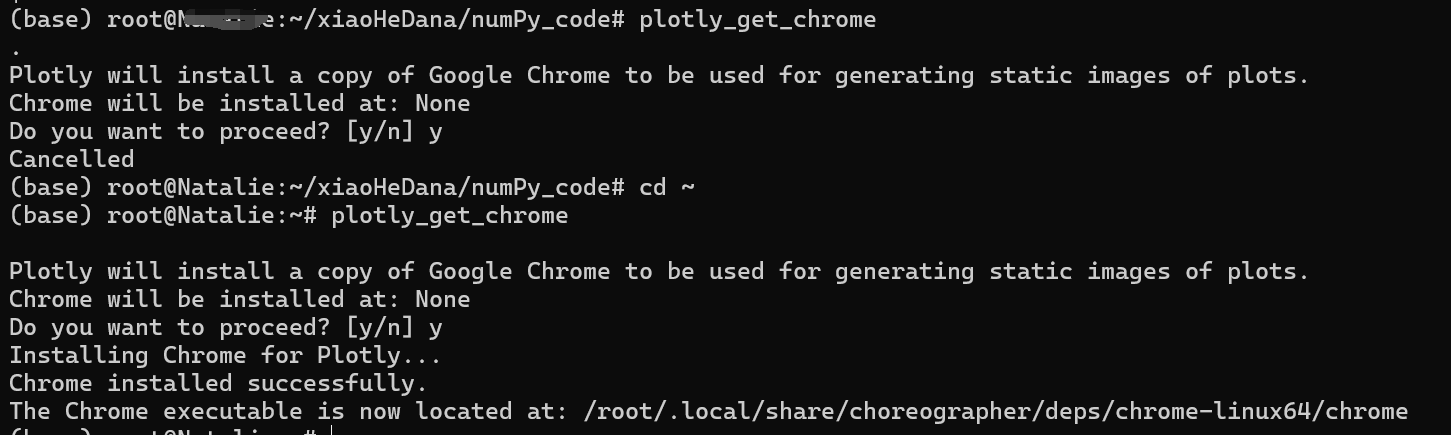

In [2]:
# !pip install plotly
# !pip install 'plotly[kaleido]'
import kaleido #required
import plotly.express as px            # 高层 API，快速绘图
import plotly.graph_objects as go      # 低层 API，精细控制
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np


Plotly 有两套 API：
- `plotly.express`（简称 `px`）：一行代码，类似 Seaborn 的风格
- `plotly.graph_objects`（简称 `go`）：更灵活，适合复杂图表

---

## 二、plotly.express 快速上手

### 折线图

折线图擅长展示趋势变化，来画一个：


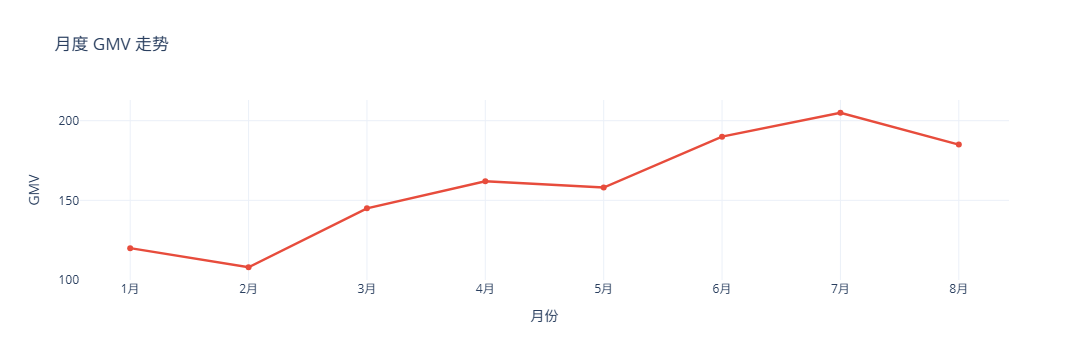

In [3]:
import plotly.express as px
import pandas as pd

months = ['1月','2月','3月','4月','5月','6月','7月','8月']
gmv    = [120, 108, 145, 162, 158, 190, 205, 185]

df = pd.DataFrame({'月份': months, 'GMV': gmv})

fig = px.line(df, x='月份', y='GMV',
               title='月度 GMV 走势',
               markers=True,
               template='plotly_white')
fig.update_traces(line_color='#E74C3C', line_width=2.5)
fig.show()


在 Jupyter 里运行，你会看到一个可以鼠标悬停的折线图——每个点都会弹出数据标签。

---

### 柱状图

柱状图是最常用的对比图表，先来画一个：


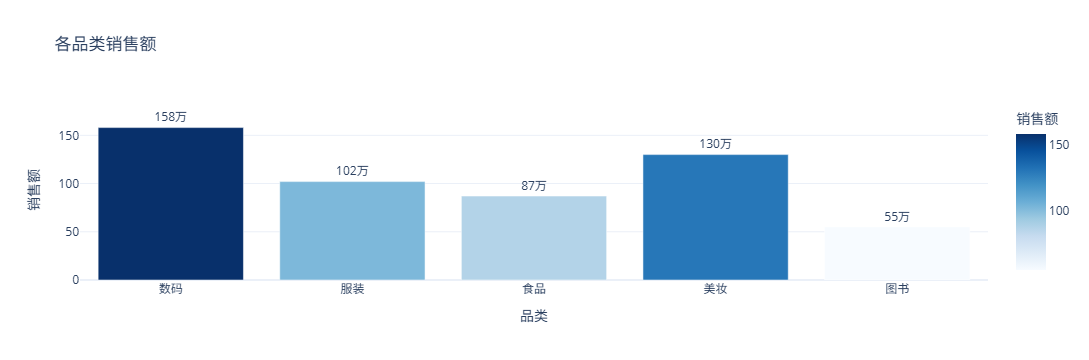

In [4]:
categories = ['数码', '服装', '食品', '美妆', '图书']
sales      = [158, 102, 87, 130, 55]

df_bar = pd.DataFrame({'品类': categories, '销售额': sales})

fig = px.bar(df_bar, x='品类', y='销售额',
              title='各品类销售额',
              color='销售额',
              color_continuous_scale='Blues',
              template='plotly_white')
fig.update_traces(texttemplate='%{y}万', textposition='outside')
fig.show()


---

### 散点图（带颜色和大小编码）

散点图用于展示两个变量的关系，来画一个：


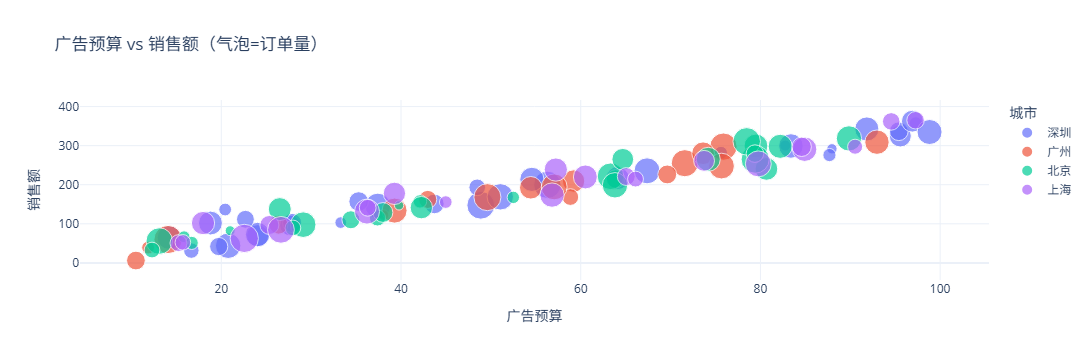

In [5]:
np.random.seed(42)
n = 100
df_scatter = pd.DataFrame({
    '广告预算': np.random.uniform(10, 100, n),
    '销售额':  np.random.uniform(50, 500, n),
    '城市':   np.random.choice(['北京','上海','广州','深圳'], n),
    '订单量': np.random.randint(50, 500, n)
})
df_scatter['销售额'] = df_scatter['广告预算'] * 3.5 + np.random.normal(0, 20, n)

fig = px.scatter(df_scatter,
                  x='广告预算', y='销售额',
                  color='城市',
                  size='订单量',
                  hover_name='城市',
                  title='广告预算 vs 销售额（气泡=订单量）',
                  template='plotly_white')
fig.show()


`hover_name` 让鼠标悬停时显示城市名，`size` 让气泡大小代表订单量。

---

### 热力图

力图用红色/蓝色直观展示特征对预测的影响：


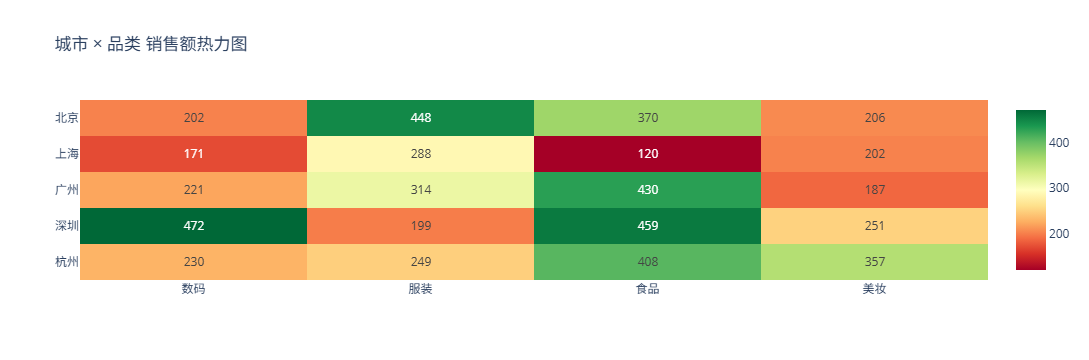

In [6]:
import plotly.express as px
import numpy as np
import pandas as pd

np.random.seed(42)
df_pivot = pd.DataFrame(
    np.random.randint(100, 500, (5, 4)),
    index=['北京','上海','广州','深圳','杭州'],
    columns=['数码','服装','食品','美妆']
)

fig = px.imshow(df_pivot,
                 text_auto=True,
                 color_continuous_scale='RdYlGn',
                 title='城市 × 品类 销售额热力图',
                 aspect='auto')
fig.show()


---

## 三、graph_objects：精细控制

`go` 更灵活，适合需要自定义的场景：


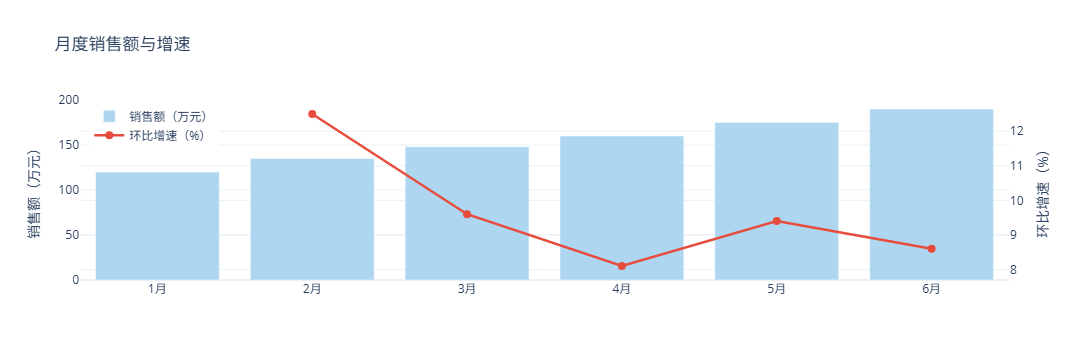

In [7]:
import plotly.graph_objects as go

# 双坐标轴图（折线+柱状图组合）
months = ['1月','2月','3月','4月','5月','6月']
sales  = [120, 135, 148, 160, 175, 190]
growth = [None, 12.5, 9.6, 8.1, 9.4, 8.6]  # 环比增速

fig = go.Figure()

# 柱状图（左轴）
fig.add_trace(go.Bar(
    x=months, y=sales,
    name='销售额（万元）',
    marker_color='#AED6F1',
    yaxis='y1'
))

# 折线图（右轴）
fig.add_trace(go.Scatter(
    x=months, y=growth,
    name='环比增速（%）',
    mode='lines+markers',
    line=dict(color='#E74C3C', width=2.5),
    marker=dict(size=8),
    yaxis='y2'
))

fig.update_layout(
    title='月度销售额与增速',
    yaxis=dict(title='销售额（万元）'),
    yaxis2=dict(title='环比增速（%）', overlaying='y', side='right'),
    template='plotly_white',
    legend=dict(x=0.01, y=0.99),
    hovermode='x unified'    # 悬停时显示该x点的所有值
)
fig.show()


---

## 四、多子图：make_subplots

一张图里放多个子图，信息密度更高，对比也更方便：


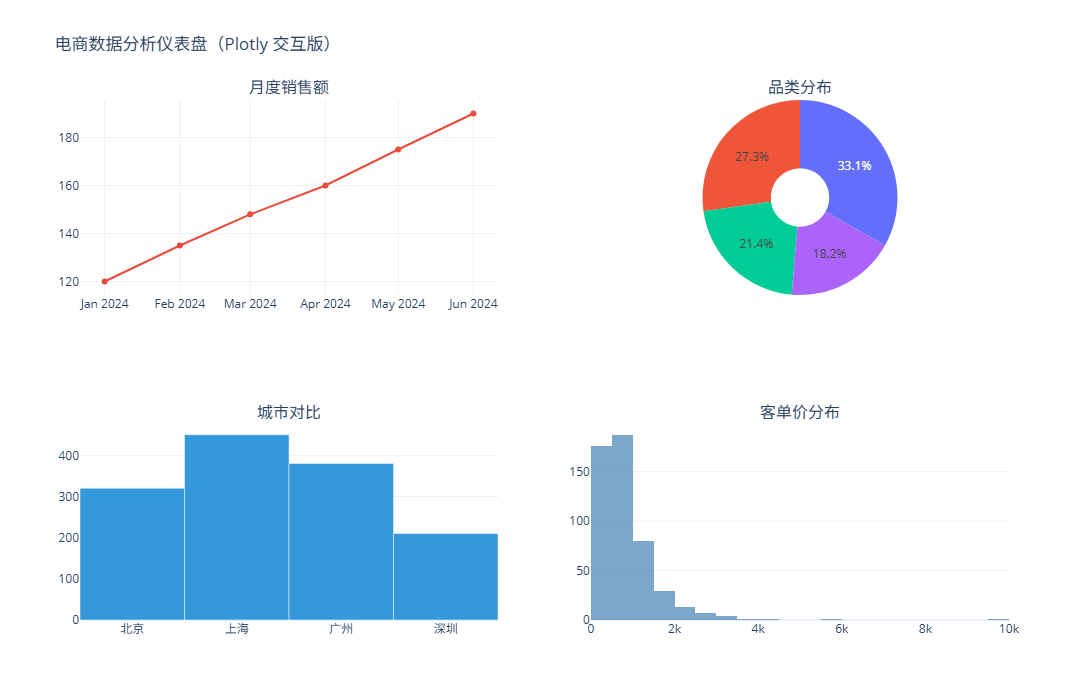

In [19]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2, cols=2,
    # 定义每个子图的类型：默认xy，饼图位置设为domain
    specs=[
        [{"type": "xy"}, {"type": "domain"}],  # 第1行：左xy图，右domain图（放饼图）
        [{"type": "xy"}, {"type": "xy"}]       # 第2行：均为xy图（可放柱状图/折线图）
    ],
    subplot_titles=['月度销售额', '品类分布', '城市对比', '客单价分布']
)

# 子图1：折线
fig.add_trace(go.Scatter(x=months[:6], y=sales,
    mode='lines+markers', line=dict(color='#E74C3C')), row=1, col=1)

# 子图2：饼图
fig.add_trace(go.Pie(labels=['数码','服装','食品','美妆'],
    values=[158, 102, 87, 130], hole=0.3), row=1, col=2)

# 子图3：柱状图
fig.add_trace(go.Bar(x=['北京','上海','广州','深圳'],
    y=[320, 450, 380, 210], marker_color='#3498DB'), row=2, col=1)

# 子图4：直方图
np.random.seed(42)
amounts = np.random.lognormal(6.5, 0.7, 500)
fig.add_trace(go.Histogram(x=amounts, nbinsx=30,
    marker_color='steelblue', opacity=0.7), row=2, col=2)

fig.update_layout(
    height=700, title_text='电商数据分析仪表盘（Plotly 交互版）',
    template='plotly_white', showlegend=False
)
fig.show()


---

## 五、保存为 HTML 文件

Plotly 图表可以保存为 HTML，发给任何人打开浏览器即可交互：


In [11]:

# 保存为 HTML
fig.write_html('dashboard.html')

# 保存为静态 PNG（需要安装 kaleido）
fig.write_image('dashboard.png', width=1200, height=700, scale=2)

print("已保存为 dashboard.html")


已保存为 dashboard.html


---

## 六、Plotly vs Matplotlib 选型

| 维度 | Plotly | Matplotlib |
|------|--------|------------|
| 交互性 | 内置 | 需要额外工具 |
| 适合 Jupyter | ✅ | ✅ |
| 适合 Web | ✅ | 需转图片 |
| 适合 PDF/报告 | 需额外设置 | ✅ |
| 上手难度 | 中等 | 中等 |
| 图表类型 | 丰富（含 3D、地图） | 丰富 |

**实际建议**：
- 日常探索分析 → Plotly（方便交互）
- 最终报告/PPT → Matplotlib + Seaborn（方便精细调整）
- 发给非技术人员 → Plotly 导出 HTML

---

## 七、📝 小结

Plotly 的三大优势：
1. **交互性**：鼠标悬停、缩放、筛选图例，探索数据更方便
2. **美观**：默认样式比 Matplotlib 好看
3. **分享方便**：一键导出 HTML，无需安装 Python 即可查看

---

## 八、🏋️ 课后练习

1. 用 `px.line` 画一张月度 GMV 折线图，鼠标悬停确认能看到每个点的数值。
2. 用 `make_subplots` 做一个 2×2 的交互仪表盘，包含折线、柱状、饼图、散点各一张。
3. 把仪表盘导出为 HTML 文件，用浏览器打开验证交互效果。

In [14]:
# ============================================================
# 准备数据（复用第18篇实战数据风格）
# ============================================================
np.random.seed(2024)

months = ['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06',
          '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12']

# 月度 GMV 数据（带一定增长趋势 + 随机波动）
base_gmv = 5000
gmv = [base_gmv + i * 300 + np.random.randint(-200, 300) for i in range(12)]
gmv_df = pd.DataFrame({'月份': months, 'GMV': gmv})

# 品类销售额数据（用于饼图）
categories = ['数码', '服装', '食品', '美妆', '图书', '运动']
cat_sales = [1580, 1320, 980, 870, 650, 720]

# 城市销售额数据（用于柱状图）
cities = ['北京', '上海', '广州', '深圳', '杭州', '成都', '武汉']
city_sales = [3200, 4100, 2800, 3500, 1900, 2100, 1800]
city_df = pd.DataFrame({'城市': cities, '销售额': city_sales})

# 散点图数据：广告预算 vs 销售额
n = 50
scatter_df = pd.DataFrame({
    '广告预算': np.random.uniform(10, 100, n),
    '销售额': np.random.uniform(500, 5000, n),
    '城市': np.random.choice(['北京', '上海', '广州', '深圳', '杭州'], n),
    '品类': np.random.choice(categories[:4], n)
})
# 让销售额和广告预算有一定相关性
scatter_df['销售额'] = scatter_df['广告预算'] * 40 + np.random.normal(0, 500, n)

print("数据准备完成！")
print(f"月度 GMV 数据：{len(gmv_df)} 条")
print(f"品类数据：{len(categories)} 类")
print(f"城市数据：{len(cities)} 个")
print(f"散点数据：{len(scatter_df)} 条")

数据准备完成！
月度 GMV 数据：12 条
品类数据：6 类
城市数据：7 个
散点数据：50 条



练习1：px.line 月度 GMV 折线图


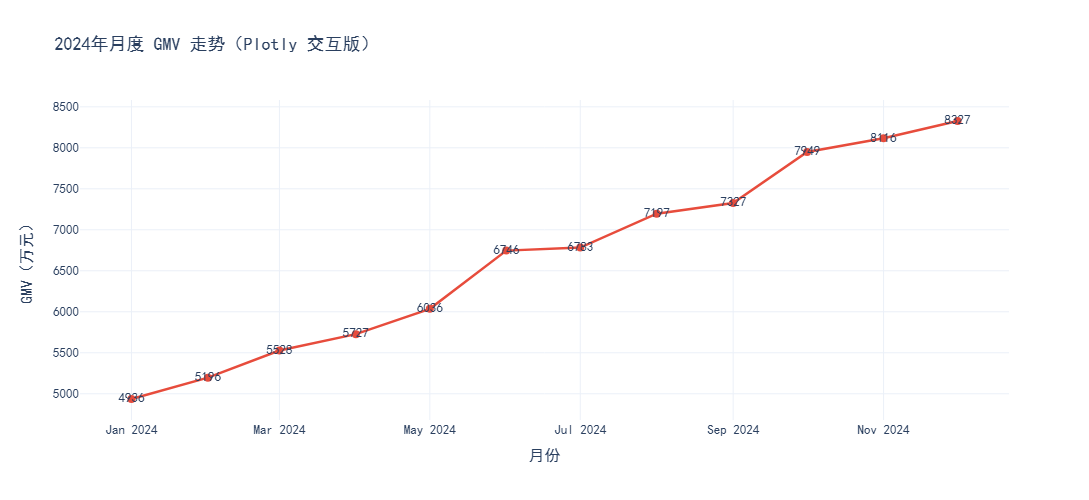

In [21]:
# ============================================================
# 练习1：px.line 画月度 GMV 折线图
# ============================================================
print("\n" + "="*50)
print("练习1：px.line 月度 GMV 折线图")
print("="*50)

fig1 = px.line(
    gmv_df,
    x='月份',
    y='GMV',
    title='2024年月度 GMV 走势（Plotly 交互版）',
    markers=True,          # 显示数据点
    text='GMV',            # 悬停显示 GMV 值
    template='plotly_white'
)

# 悬停时显示每个点的具体数值（hover_data 可以自定义显示字段）
fig1.update_traces(
    line_color='#E74C3C',
    line_width=2.5,
    marker=dict(size=8, color='#E74C3C'),
    hovertemplate='<b>%{x}</b><br>GMV: ¥%{y:,.0f}<extra></extra>'
)

fig1.update_layout(
    xaxis_title='月份',
    yaxis_title='GMV（万元）',
    font=dict(family='SimHei, WenQuanYi Micro Hei, sans-serif', size=13),
    height=500
)



练习2：make_subplots 2×2 交互仪表盘


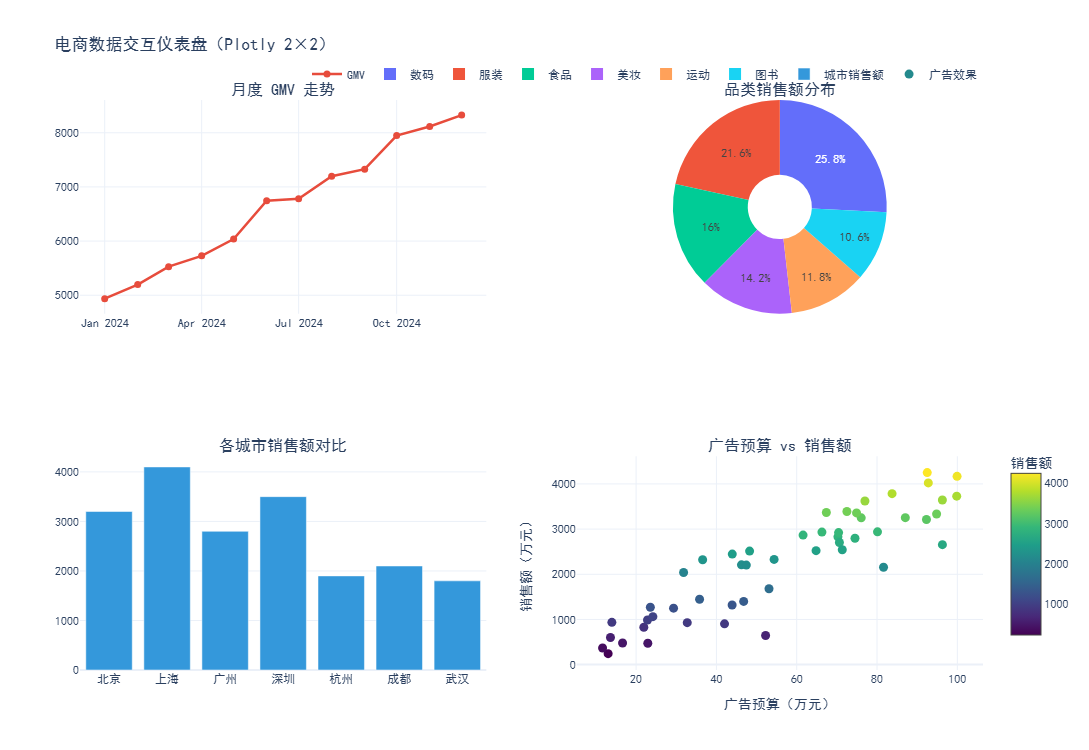

In [22]:
# ============================================================
# 练习2：make_subplots 2×2 交互仪表盘
# ============================================================
print("\n" + "="*50)
print("练习2：make_subplots 2×2 交互仪表盘")
print("="*50)

# 关键：用 specs 指定每个子图的类型
# 饼图需要 type='domain'，其他用 type='xy'
fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=('月度 GMV 走势', '品类销售额分布', '各城市销售额对比', '广告预算 vs 销售额'),
    specs=[
        [{"type": "xy"},     {"type": "domain"}],   # 第1行：折线(xy) + 饼图(domain)
        [{"type": "xy"},     {"type": "xy"}]       # 第2行：柱状(xy) + 散点(xy)
    ]
)

# ── 子图1：月度 GMV 折线图 ──
fig2.add_trace(
    go.Scatter(
        x=gmv_df['月份'],
        y=gmv_df['GMV'],
        mode='lines+markers',
        name='GMV',
        line=dict(color='#E74C3C', width=2.5),
        marker=dict(size=7),
        hovertemplate='%{x}<br>GMV: ¥%{y:,.0f}<extra></extra>'
    ),
    row=1, col=1
)

# ── 子图2：品类销售额饼图（需要 domain 类型子图）──
fig2.add_trace(
    go.Pie(
        labels=categories,
        values=cat_sales,
        hole=0.3,
        name='品类分布',
        hovertemplate='%{label}<br>销售额: ¥%{value}万<br>占比: %{percent}<extra></extra>'
    ),
    row=1, col=2
)

# ── 子图3：各城市销售额柱状图 ──
fig2.add_trace(
    go.Bar(
        x=city_df['城市'],
        y=city_df['销售额'],
        name='城市销售额',
        marker_color='#3498DB',
        hovertemplate='%{x}<br>销售额: ¥%{y}万<extra></extra>'
    ),
    row=2, col=1
)

# ── 子图4：广告预算 vs 销售额 散点图 ──
fig2.add_trace(
    go.Scatter(
        x=scatter_df['广告预算'],
        y=scatter_df['销售额'],
        mode='markers',
        name='广告效果',
        marker=dict(
            size=9,
            color=scatter_df['销售额'],
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="销售额", x=1.02, y=0.22, len=0.35)
        ),
        text=scatter_df['城市'],
        hovertemplate='城市: %{text}<br>广告预算: %{x:.1f}万<br>销售额: ¥%{y:,.0f}<extra></extra>'
    ),
    row=2, col=2
)

# 更新布局
fig2.update_layout(
    title_text='电商数据交互仪表盘（Plotly 2×2）',
    height=750,
    template='plotly_white',
    font=dict(family='SimHei, WenQuanYi Micro Hei, sans-serif', size=12),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)

# 散点图坐标轴标签
fig2.update_xaxes(title_text='广告预算（万元）', row=2, col=2)
fig2.update_yaxes(title_text='销售额（万元）', row=2, col=2)


In [25]:
print("\n" + "="*50)
print("练习3：导出为 HTML 文件")
print("="*50)


fig2.write_html(
    'prac-dashboard.png',
    config={
        'displayModeBar': True,           # 显示工具栏
        'responsive': True,               # 自适应屏幕
        'displaylogo': False,             # 去掉 Plotly logo
        'modeBarButtonsToRemove': ['select2d', 'lasso2d']  # 去掉不必要的按钮
    }
)

print(f"✅ 练习3完成：仪表盘已导出为 HTML")
print(f"   用浏览器打开即可查看交互效果！")

# 也把折线图单独导出
fig1.write_html('prac-dashboard.html',config={'displaylogo': False, 'responsive': True})
print(f"\n额外导出：月度 GMV 折线图已单独保存为 HTML")



练习3：导出为 HTML 文件
✅ 练习3完成：仪表盘已导出为 HTML
   用浏览器打开即可查看交互效果！

额外导出：月度 GMV 折线图已单独保存为 HTML


本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 27 篇：图表选择指南**
>
> 可视化内容即将收官！下篇来梳理图表选择指南——什么数据该用什么图，避开 90% 的可视化误区。

---

*跟着小荷，数据分析路上不迷路～*